In [2]:
!pip install -q pennylane pennylane-lightning gdown

import os, shutil, zipfile, pickle, time, json, glob
import numpy as np, torch, torch.nn as nn, pennylane as qml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42; np.random.seed(SEED); torch.manual_seed(SEED)
n_qubits, n_layers, SNR_MIN = 6, 4, 0
print("device:", device)   # must say cuda — if cpu, Runtime > Change runtime type > T4 GPU

FILE_ID = "1ConKzsl-LYY4vl6FsoPBBtaLiyluqGzU"
if not os.path.exists("/content/backup.zip"):
    !gdown {FILE_ID} -O /content/backup.zip
sz = os.path.getsize("/content/backup.zip")/1e6
print(f"zip: {sz:.0f} MB")
assert sz > 100, "download failed (got an HTML page?) — set link sharing to 'Anyone with the link'"

if not os.path.exists("/content/bk"):
    t0 = time.time()
    with zipfile.ZipFile("/content/backup.zip") as z: z.extractall("/content/bk")
    print(f"extracted in {time.time()-t0:.0f}s")
print(sorted(os.listdir("/content/bk")))

device: cuda
Downloading...
From (original): https://drive.google.com/uc?id=1ConKzsl-LYY4vl6FsoPBBtaLiyluqGzU
From (redirected): https://drive.google.com/uc?id=1ConKzsl-LYY4vl6FsoPBBtaLiyluqGzU&confirm=t&uuid=44a78b8a-953d-4e77-a96d-fd429dd47de5
To: /content/backup.zip
100% 209M/209M [00:05<00:00, 36.2MB/s]
zip: 209 MB
extracted in 2s
['ALL_RESULTS_master.pkl', 'RML2016.10a_dict.pkl', 'meta_summary.json', 'model_ext_hard.pt', 'model_ext_lo.pt', 'model_raw.pt', 'results_1b_novel.pkl', 'results_1c_hard.pkl', 'results_1d_frozen.pkl', 'results_1e_ceiling.pkl', 'validity_check_K20.pkl']


In [3]:
PKL = "/content/bk/RML2016.10a_dict.pkl"
assert os.path.exists(PKL), "dataset missing from zip"

raw_d = pickle.load(open(PKL, "rb"), encoding="latin1")
mods = sorted({k[0] for k in raw_d}); mod_to_idx = {m: i for i, m in enumerate(mods)}
X, y, S = [], [], []
for (m, s), arr in raw_d.items():
    X.append(arr); y += [mod_to_idx[m]]*arr.shape[0]; S += [s]*arr.shape[0]
X = np.vstack(X).astype(np.float32); y = np.array(y); S = np.array(S)
X = X / (np.sqrt((X**2).sum(axis=(1,2), keepdims=True)) + 1e-8)
del raw_d                                   # free ~900MB before the heavy cells

Xtr,Xtmp,ytr,ytmp,Str,Stmp = train_test_split(X,y,S,test_size=0.4,random_state=SEED,stratify=y)
Xva,Xte,yva,yte,Sva,Ste = train_test_split(Xtmp,ytmp,Stmp,test_size=0.5,random_state=SEED,stratify=ytmp)
print("X:", X.shape, "| classes:", len(mods), "| split:", len(ytr), len(yva), len(yte))

X: (220000, 2, 128) | classes: 11 | split: 132000 44000 44000


In [4]:
class FeatureExtractor(nn.Module):
    def __init__(self, d, L=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2,32,3,padding=1), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3),
            nn.Conv1d(32,32,3,padding=1), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3))
        self.bottleneck = nn.Sequential(nn.Flatten(), nn.Linear(32*32, d), nn.Tanh())
    def forward(self, x): return self.bottleneck(self.features(x))

class ClassicalHead(nn.Module):
    def __init__(self, d, n_classes, hidden=64, p=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,hidden), nn.ReLU(), nn.Dropout(p),
                                 nn.Linear(hidden,hidden), nn.ReLU(), nn.Dropout(p),
                                 nn.Linear(hidden,n_classes))
    def forward(self, x): return self.net(x)

class LinearHead(nn.Module):
    def __init__(self, d, n_classes):
        super().__init__(); self.net = nn.Linear(d, n_classes)
    def forward(self, x): return self.net(x)

class RawCNN(nn.Module):
    def __init__(self, n_classes, L=128):
        super().__init__()
        self.f = nn.Sequential(nn.Conv1d(2,64,3,padding=1), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3),
                               nn.Conv1d(64,64,3,padding=1), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3))
        self.c = nn.Sequential(nn.Flatten(), nn.Linear(64*32,128), nn.ReLU(),
                               nn.Dropout(0.3), nn.Linear(128,n_classes))
    def forward(self, x): return self.c(self.f(x))

try:    qdev = qml.device("lightning.qubit", wires=n_qubits); QDIFF="adjoint"
except Exception: qdev = qml.device("default.qubit", wires=n_qubits); QDIFF="backprop"

@qml.qnode(qdev, interface="torch", diff_method=QDIFF)
def qnode_ru(inputs, weights):
    for l in range(n_layers):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        qml.StronglyEntanglingLayers(weights[l:l+1], wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
ru_shapes = {"weights": (n_layers, n_qubits, 3)}

class QuantumHeadRU(nn.Module):
    def __init__(self, d, n_classes, n_layers):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_ru, ru_shapes); self.out = nn.Linear(d, n_classes)
    def forward(self, x): return self.out(self.qlayer(x * np.pi))

def extract(ext, Xa, bs=1024):
    outs = []
    with torch.no_grad():
        for i in range(0, len(Xa), bs):
            outs.append(ext(torch.tensor(Xa[i:i+bs]).to(device)).cpu().numpy())
    return np.concatenate(outs)

def knn_predict(Fk, yk, Fq, k=1):
    from scipy.stats import mode
    d2 = np.sum((Fq[:,None,:] - Fk[None,:,:])**2, axis=2)
    return mode(yk[np.argsort(d2,axis=1)[:,:min(k,len(yk))]], axis=1, keepdims=False).mode

def sample_episode(Xp, yp, classes, n_way, k_shot, q_query, rng):
    chosen = rng.choice(classes, size=n_way, replace=False)
    sup, qry, remap = [], [], {c:i for i,c in enumerate(chosen)}
    for c in chosen:
        pick = rng.choice(np.where(yp==c)[0], size=k_shot+q_query, replace=False)
        sup.append(pick[:k_shot]); qry.append(pick[k_shot:])
    sup, qry = np.concatenate(sup), np.concatenate(qry)
    return Xp[sup], np.array([remap[c] for c in yp[sup]]), Xp[qry], np.array([remap[c] for c in yp[qry]])

def proto_loss(es, ys, eq, yq, n_way):
    protos = torch.stack([es[ys==c].mean(0) for c in range(n_way)])
    logits = -(torch.cdist(eq, protos)**2)
    return nn.functional.cross_entropy(logits, torch.tensor(yq, device=eq.device)), logits

def full_data_mlp(Ftr_, ytr_, Fte_, yte_, n_classes, hidden=64, epochs=200, lr=1e-2):
    net = nn.Sequential(nn.Linear(Ftr_.shape[1],hidden), nn.ReLU(),
                        nn.Linear(hidden,hidden), nn.ReLU(), nn.Linear(hidden,n_classes)).to(device)
    Xk = torch.tensor(Ftr_,dtype=torch.float32).to(device); Yk = torch.tensor(ytr_,dtype=torch.long).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr); crit = nn.CrossEntropyLoss()
    for _ in range(epochs): opt.zero_grad(); crit(net(Xk),Yk).backward(); opt.step()
    net.eval()
    with torch.no_grad():
        return (net(torch.tensor(Fte_,dtype=torch.float32).to(device)).argmax(1).cpu().numpy()==yte_).mean()

def train_head_full(make_head, Fk, yk, epochs=80, lr=1e-2, bs=512):
    head = make_head(); Xk = torch.tensor(Fk,dtype=torch.float32); Yk = torch.tensor(yk,dtype=torch.long)
    opt = torch.optim.Adam(head.parameters(), lr=lr); crit = nn.CrossEntropyLoss(); head.train()
    for _ in range(epochs):
        pm = torch.randperm(len(Yk))[:bs]
        opt.zero_grad(); crit(head(Xk[pm]), Yk[pm]).backward(); opt.step()
    head.eval(); return head

print("library ready | quantum:", qdev.name, QDIFF)

library ready | quantum: lightning.qubit adjoint


In [5]:
BK = "/content/bk"
NOVEL_HARD = ["QAM16","QAM64","8PSK","AM-DSB"]
novel_c = sorted(mod_to_idx[m] for m in NOVEL_HARD)
base_c  = sorted(i for i in range(len(mods)) if i not in novel_c)

ntr = np.where((Str>=SNR_MIN) & (np.isin(ytr,novel_c)))[0]
nte = np.where((Ste>=SNR_MIN) & (np.isin(yte,novel_c)))[0]
remap = {c:i for i,c in enumerate(novel_c)}
Xtr_h, ytr_h = Xtr[ntr], np.array([remap[c] for c in ytr[ntr]])
Xte_h, yte_h = Xte[nte], np.array([remap[c] for c in yte[nte]])

ext_hard = FeatureExtractor(n_qubits).to(device)
ext_hard.load_state_dict(torch.load(f"{BK}/model_ext_hard.pt", map_location=device)); ext_hard.eval()
ext_lo = FeatureExtractor(n_qubits).to(device)
ext_lo.load_state_dict(torch.load(f"{BK}/model_ext_lo.pt", map_location=device)); ext_lo.eval()
for p in list(ext_hard.parameters())+list(ext_lo.parameters()): p.requires_grad_(False)

Ftr_h, Fte_h = extract(ext_hard, Xtr_h), extract(ext_hard, Xte_h)
rng0 = np.random.default_rng(7777)
qi = rng0.choice(len(Fte_h), size=min(1000,len(Fte_h)), replace=False)
Fq_h, yq_h = Fte_h[qi], yte_h[qi]

prior = {f.replace(".pkl",""): pickle.load(open(f"{BK}/{f}","rb"))
         for f in os.listdir(BK) if f.endswith(".pkl") and "RML" not in f}
acc_raw = prior["results_1e_ceiling"]["raw_cnn"]

v_probe = LogisticRegression(max_iter=500).fit(Ftr_h, ytr_h).score(Fte_h, yte_h)
print(f"novelty check  : {v_probe:.3f}   (expected 0.517)")
print(f"raw-CNN ceiling: {acc_raw:.3f}   (expected 0.744)")
print(f"prior results  : {sorted(prior)}")
assert abs(v_probe-0.517) < 0.02, "feature mismatch — check restore"
print("\n✅ verified — Exp 1b/1c/1d/1e intact. Next: R5 (Exp 2), then R6 (Exp 1f).")

novelty check  : 0.517   (expected 0.517)
raw-CNN ceiling: 0.744   (expected 0.744)
prior results  : ['ALL_RESULTS_master', 'results_1b_novel', 'results_1c_hard', 'results_1d_frozen', 'results_1e_ceiling', 'validity_check_K20']

✅ verified — Exp 1b/1c/1d/1e intact. Next: R5 (Exp 2), then R6 (Exp 1f).


low-SNR pools: 33016 11117
training raw-CNN low-SNR control (bypasses the 6-dim bottleneck) ...
done.
  seed 0 done (662s)
  seed 1 done (1331s)
  seed 2 done (1992s)

LOW-SNR BAND (random = 0.091)
 SNR | classical_mlp |    linear     |  quantum_ru   |     knn       |  RAW-CNN (no bottleneck)
--------------------------------------------------------------------------------------------------------
  -8 | 0.201±0.008 | 0.206±0.006 | 0.158±0.010 | 0.228±0.011 | 0.223±0.000
  -6 | 0.383±0.021 | 0.356±0.034 | 0.248±0.004 | 0.373±0.013 | 0.478±0.007
  -4 | 0.436±0.023 | 0.405±0.027 | 0.324±0.015 | 0.388±0.017 | 0.560±0.011
  -2 | 0.448±0.005 | 0.404±0.011 | 0.329±0.010 | 0.420±0.007 | 0.564±0.010
   0 | 0.381±0.007 | 0.321±0.028 | 0.242±0.025 | 0.387±0.001 | 0.520±0.014

bottleneck cost per SNR (raw_cnn − best head):
   -8 dB: -0.005
   -6 dB: +0.095
   -4 dB: +0.123
   -2 dB: +0.116
    0 dB: +0.133


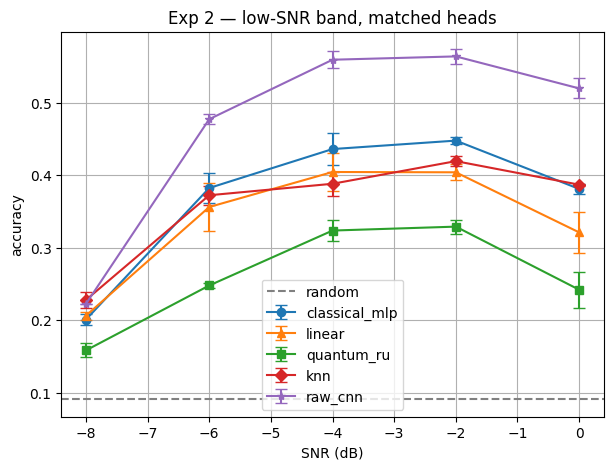

=== Exp 2 complete (1992s) ===


In [6]:
SNR_BAND = [-8,-6,-4,-2,0]; SEEDS_S = [0,1,2]
lo_tr = np.where((Str>=-8)&(Str<=0))[0]; Xlo, ylo = Xtr[lo_tr], ytr[lo_tr]
lo_te = np.where((Ste>=-8)&(Ste<=0))[0]; Xlo_te, ylo_te, Slo_te = Xte[lo_te], yte[lo_te], Ste[lo_te]
Flo_tr, Flo_te = extract(ext_lo, Xlo), extract(ext_lo, Xlo_te)
print("low-SNR pools:", len(ylo), len(ylo_te))

print("training raw-CNN low-SNR control (bypasses the 6-dim bottleneck) ...")
rcnn = RawCNN(len(mods)).to(device); opt = torch.optim.Adam(rcnn.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
ld = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.tensor(Xlo), torch.tensor(ylo,dtype=torch.long)), batch_size=256, shuffle=True)
for ep in range(20):
    rcnn.train()
    for xb,yb in ld:
        xb,yb = xb.to(device), yb.to(device)
        opt.zero_grad(); crit(rcnn(xb),yb).backward(); opt.step()
rcnn.eval(); print("done.")

rng_s = np.random.default_rng(SEED)
sub = rng_s.choice(len(ylo), size=min(4000,len(ylo)), replace=False)
Fsub, ysub = Flo_tr[sub], ylo[sub]
res_snr = {m:{s:[] for s in SNR_BAND} for m in ["classical_mlp","linear","quantum_ru","knn","raw_cnn"]}

t0 = time.time()
for seed in SEEDS_S:
    torch.manual_seed(seed)
    heads = {"classical_mlp": train_head_full(lambda: ClassicalHead(n_qubits,len(mods)), Fsub, ysub),
             "linear":        train_head_full(lambda: LinearHead(n_qubits,len(mods)), Fsub, ysub),
             "quantum_ru":    train_head_full(lambda: QuantumHeadRU(n_qubits,len(mods),n_layers), Fsub, ysub)}
    for snr in SNR_BAND:
        mi = np.where(Slo_te==snr)[0]; ev = rng_s.choice(mi, size=min(800,len(mi)), replace=False)
        Fq, yq = Flo_te[ev], ylo_te[ev]
        for nm,h in heads.items():
            with torch.no_grad():
                res_snr[nm][snr].append((h(torch.tensor(Fq,dtype=torch.float32)).argmax(1).numpy()==yq).mean())
        res_snr["knn"][snr].append((knn_predict(Fsub[:1100], ysub[:1100], Fq, k=15)==yq).mean())
        with torch.no_grad():
            res_snr["raw_cnn"][snr].append(
                (rcnn(torch.tensor(Xlo_te[ev]).to(device)).argmax(1).cpu().numpy()==yq).mean())
    print(f"  seed {seed} done ({time.time()-t0:.0f}s)", flush=True)

print(f"\nLOW-SNR BAND (random = {1/len(mods):.3f})")
print(" SNR | classical_mlp |    linear     |  quantum_ru   |     knn       |  RAW-CNN (no bottleneck)")
print("-"*104)
for snr in SNR_BAND:
    r = [f"{np.mean(res_snr[m][snr]):.3f}±{np.std(res_snr[m][snr]):.3f}"
         for m in ["classical_mlp","linear","quantum_ru","knn","raw_cnn"]]
    print(f"{snr:4d} | {r[0]} | {r[1]} | {r[2]} | {r[3]} | {r[4]}")
print("\nbottleneck cost per SNR (raw_cnn − best head):")
for snr in SNR_BAND:
    bh = max(np.mean(res_snr[m][snr]) for m in ["classical_mlp","linear","quantum_ru","knn"])
    print(f"  {snr:3d} dB: {np.mean(res_snr['raw_cnn'][snr])-bh:+.3f}")

plt.figure(figsize=(7,5))
for nm,(mk,cl) in {"classical_mlp":("o","C0"),"linear":("^","C1"),"quantum_ru":("s","C2"),
                   "knn":("D","C3"),"raw_cnn":("*","C4")}.items():
    plt.errorbar(SNR_BAND, [np.mean(res_snr[nm][s]) for s in SNR_BAND],
                 yerr=[np.std(res_snr[nm][s]) for s in SNR_BAND], marker=mk, color=cl, capsize=4, label=nm)
plt.axhline(1/len(mods), ls='--', c='gray', label='random')
plt.xlabel("SNR (dB)"); plt.ylabel("accuracy"); plt.title("Exp 2 — low-SNR band, matched heads")
plt.legend(); plt.grid(True); plt.show()
pickle.dump({"res_snr":res_snr,"SNR_BAND":SNR_BAND}, open("results_2_lowsnr.pkl","wb"))
print(f"=== Exp 2 complete ({time.time()-t0:.0f}s) ===")

novel set ['QAM16', 'QAM64', '8PSK', 'AM-DSB'] | raw-CNN reference 0.744 | random 0.250
7 widths x 3 seeds

  d= 2 seed 0 | acc 0.622 | proto-loss 0.884 (51s)
  d= 2 seed 1 | acc 0.505 | proto-loss 1.395 (91s)
  d= 2 seed 2 | acc 0.511 | proto-loss 1.036 (133s)
  d= 4 seed 0 | acc 0.733 | proto-loss 0.561 (165s)
  d= 4 seed 1 | acc 0.525 | proto-loss 1.028 (207s)
  d= 4 seed 2 | acc 0.674 | proto-loss 0.699 (244s)
  d= 6 seed 0 | acc 0.537 | proto-loss 0.784 (286s)
  d= 6 seed 1 | acc 0.615 | proto-loss 0.614 (325s)
  d= 6 seed 2 | acc 0.676 | proto-loss 0.535 (361s)
  d= 8 seed 0 | acc 0.589 | proto-loss 0.656 (405s)
  d= 8 seed 1 | acc 0.566 | proto-loss 0.559 (449s)
  d= 8 seed 2 | acc 0.683 | proto-loss 0.433 (486s)
  d=12 seed 0 | acc 0.671 | proto-loss 0.479 (526s)
  d=12 seed 1 | acc 0.727 | proto-loss 0.415 (561s)
  d=12 seed 2 | acc 0.687 | proto-loss 0.415 (599s)
  d=16 seed 0 | acc 0.662 | proto-loss 0.495 (640s)
  d=16 seed 1 | acc 0.718 | proto-loss 0.426 (676s)
  d=16 see

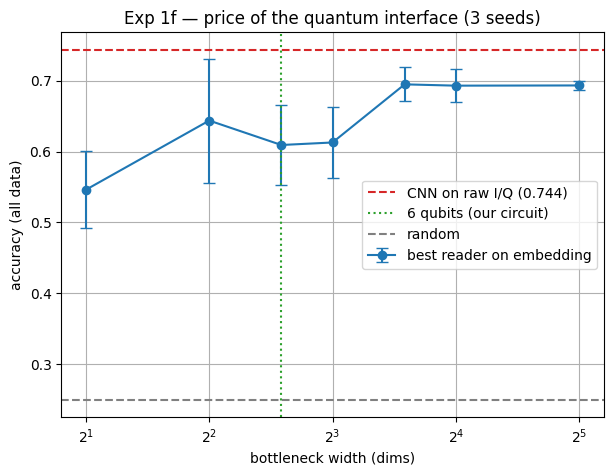

saved -> results_1f_width_v2.pkl


In [7]:
WIDTHS = [2,4,6,8,12,16,32]; W_SEEDS = [0,1,2]; EPISODES = 2500

class WidthFE(nn.Module):
    """Identical architecture at every width — only the bottleneck dim changes."""
    def __init__(self, dd, L=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2,32,3,padding=1), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3),
            nn.Conv1d(32,32,3,padding=1), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3))
        self.bottleneck = nn.Sequential(nn.Flatten(), nn.Linear(32*32, dd), nn.Tanh())
    def forward(self, x): return self.bottleneck(self.features(x))

def train_width_extractor(d, base_classes, seed, episodes=EPISODES):
    """ONE code path for all widths (this is what the buggy v1 got wrong)."""
    tp = np.where((Str>=SNR_MIN) & (np.isin(ytr, base_classes)))[0]
    Xp, yp = Xtr[tp], ytr[tp]
    torch.manual_seed(seed)
    ext = WidthFE(d).to(device); opt = torch.optim.Adam(ext.parameters(), lr=1e-3)
    rng = np.random.default_rng(seed); losses = []; ext.train()
    for _ in range(episodes):
        Xs, ys, Xq_, yq_ = sample_episode(Xp, yp, base_classes, 5, 5, 15, rng)
        es = ext(torch.tensor(Xs).to(device)); eq = ext(torch.tensor(Xq_).to(device))
        loss,_ = proto_loss(es, ys, eq, yq_, 5)
        opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
    ext.eval()
    for p in ext.parameters(): p.requires_grad_(False)
    return ext, float(np.mean(losses[-100:]))

res_w = {d:{"accs":[], "losses":[]} for d in WIDTHS}
print(f"novel set {NOVEL_HARD} | raw-CNN reference {acc_raw:.3f} | random 0.250")
print(f"{len(WIDTHS)} widths x {len(W_SEEDS)} seeds\n", flush=True)
t0 = time.time()
for d in WIDTHS:
    for s in W_SEEDS:
        ext_d, fl = train_width_extractor(d, base_c, seed=s)
        Ftr_d, Fte_d = extract(ext_d, Xtr_h), extract(ext_d, Xte_h)
        a = max(LogisticRegression(max_iter=2000).fit(Ftr_d,ytr_h).score(Fte_d,yte_h),
                SVC(kernel="rbf", C=10).fit(Ftr_d,ytr_h).score(Fte_d,yte_h),
                full_data_mlp(Ftr_d, ytr_h, Fte_d, yte_h, len(novel_c)))
        res_w[d]["accs"].append(a); res_w[d]["losses"].append(fl)
        print(f"  d={d:2d} seed {s} | acc {a:.3f} | proto-loss {fl:.3f} ({time.time()-t0:.0f}s)", flush=True)

print("\nwidth | accuracy (mean±std) | gap to raw-CNN | final proto-loss")
print("-"*66)
means = []
for d in WIDTHS:
    m, sd = np.mean(res_w[d]["accs"]), np.std(res_w[d]["accs"]); means.append(m)
    print(f"{d:5d} | {m:.3f} ± {sd:.3f}      | {acc_raw-m:+.3f}        | {np.mean(res_w[d]['losses']):.3f}")

bad = [(WIDTHS[i],WIDTHS[i+1],round(means[i+1]-means[i],3))
       for i in range(len(means)-1) if means[i+1] < means[i]-0.02]
print("\nsanity — curve must be non-decreasing:")
print("  ✓ monotone within noise" if not bad else f"  ✗ non-monotone at {bad} → needs more seeds")

plt.figure(figsize=(7,5))
plt.errorbar(WIDTHS, means, yerr=[np.std(res_w[d]["accs"]) for d in WIDTHS], marker='o', capsize=4,
             label="best reader on embedding")
plt.axhline(acc_raw, ls='--', c='C3', label=f"CNN on raw I/Q ({acc_raw:.3f})")
plt.axvline(6, ls=':', c='C2', label="6 qubits (our circuit)")
plt.axhline(0.25, ls='--', c='gray', label='random')
plt.xscale('log', base=2); plt.xlabel("bottleneck width (dims)"); plt.ylabel("accuracy (all data)")
plt.title("Exp 1f — price of the quantum interface (3 seeds)")
plt.legend(); plt.grid(True); plt.show()
pickle.dump({"res_w":res_w,"WIDTHS":WIDTHS,"raw_cnn":acc_raw}, open("results_1f_width_v2.pkl","wb"))
print("saved -> results_1f_width_v2.pkl")

In [8]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/QAMC_results', exist_ok=True)
for f in ["results_2_lowsnr.pkl", "results_1f_width_v2.pkl"]:
    if os.path.exists(f):
        shutil.copy(f, f'/content/drive/MyDrive/QAMC_results/{f}'); print("saved to Drive:", f)

Mounted at /content/drive
saved to Drive: results_2_lowsnr.pkl
saved to Drive: results_1f_width_v2.pkl


In [9]:
# Cell 1f-B — resolve the 4/6/8 ambiguity with 5 additional seeds (~12 min)
EXTRA_SEEDS = [3,4,5,6,7]
for d in [4, 6, 8]:
    for s in EXTRA_SEEDS:
        ext_d, fl = train_width_extractor(d, base_c, seed=s)
        Ftr_d, Fte_d = extract(ext_d, Xtr_h), extract(ext_d, Xte_h)
        a = max(LogisticRegression(max_iter=2000).fit(Ftr_d,ytr_h).score(Fte_d,yte_h),
                SVC(kernel="rbf", C=10).fit(Ftr_d,ytr_h).score(Fte_d,yte_h),
                full_data_mlp(Ftr_d, ytr_h, Fte_d, yte_h, len(novel_c)))
        res_w[d]["accs"].append(a); res_w[d]["losses"].append(fl)
        print(f"  d={d:2d} seed {s} | acc {a:.3f} | loss {fl:.3f}", flush=True)

print("\nwidth | n | accuracy (mean±std) | proto-loss")
means=[]
for d in WIDTHS:
    m,sd = np.mean(res_w[d]["accs"]), np.std(res_w[d]["accs"]); means.append(m)
    print(f"{d:5d} | {len(res_w[d]['accs']):1d} | {m:.3f} ± {sd:.3f}      | {np.mean(res_w[d]['losses']):.3f}")
bad=[(WIDTHS[i],WIDTHS[i+1],round(means[i+1]-means[i],3))
     for i in range(len(means)-1) if means[i+1]<means[i]-0.02]
print("\n  ✓ monotone within noise" if not bad else f"\n  ✗ still non-monotone at {bad}")
pickle.dump({"res_w":res_w,"WIDTHS":WIDTHS,"raw_cnn":acc_raw}, open("results_1f_width_v3.pkl","wb"))

  d= 4 seed 3 | acc 0.623 | loss 0.691
  d= 4 seed 4 | acc 0.663 | loss 0.844
  d= 4 seed 5 | acc 0.518 | loss 0.803
  d= 4 seed 6 | acc 0.595 | loss 0.682
  d= 4 seed 7 | acc 0.550 | loss 0.969
  d= 6 seed 3 | acc 0.517 | loss 1.020
  d= 6 seed 4 | acc 0.735 | loss 0.556
  d= 6 seed 5 | acc 0.553 | loss 0.619
  d= 6 seed 6 | acc 0.651 | loss 0.586
  d= 6 seed 7 | acc 0.677 | loss 0.497
  d= 8 seed 3 | acc 0.676 | loss 0.512
  d= 8 seed 4 | acc 0.730 | loss 0.464
  d= 8 seed 5 | acc 0.571 | loss 0.598
  d= 8 seed 6 | acc 0.660 | loss 0.567
  d= 8 seed 7 | acc 0.638 | loss 0.553

width | n | accuracy (mean±std) | proto-loss
    2 | 3 | 0.546 ± 0.054      | 1.105
    4 | 8 | 0.610 ± 0.072      | 0.784
    6 | 8 | 0.620 ± 0.073      | 0.651
    8 | 8 | 0.639 ± 0.055      | 0.543
   12 | 3 | 0.695 ± 0.024      | 0.436
   16 | 3 | 0.693 ± 0.023      | 0.442
   32 | 3 | 0.693 ± 0.007      | 0.423

  ✓ monotone within noise


In [10]:
# Cell 1f-C — uniform n=8 across all widths (~13 min). Preempts the "unequal n" question.
for d in [2, 12, 16, 32]:
    for s in [3,4,5,6,7]:
        ext_d, fl = train_width_extractor(d, base_c, seed=s)
        Ftr_d, Fte_d = extract(ext_d, Xtr_h), extract(ext_d, Xte_h)
        a = max(LogisticRegression(max_iter=2000).fit(Ftr_d,ytr_h).score(Fte_d,yte_h),
                SVC(kernel="rbf", C=10).fit(Ftr_d,ytr_h).score(Fte_d,yte_h),
                full_data_mlp(Ftr_d, ytr_h, Fte_d, yte_h, len(novel_c)))
        res_w[d]["accs"].append(a); res_w[d]["losses"].append(fl)
        print(f"  d={d:2d} seed {s} | acc {a:.3f} | loss {fl:.3f}", flush=True)

print("\nwidth | n | accuracy (mean±std) | gap to raw-CNN | proto-loss")
means=[]
for d in WIDTHS:
    m,sd = np.mean(res_w[d]["accs"]), np.std(res_w[d]["accs"]); means.append(m)
    print(f"{d:5d} | {len(res_w[d]['accs']):1d} | {m:.3f} ± {sd:.3f}      | {acc_raw-m:+.3f}        | {np.mean(res_w[d]['losses']):.3f}")
bad=[(WIDTHS[i],WIDTHS[i+1],round(means[i+1]-means[i],3))
     for i in range(len(means)-1) if means[i+1]<means[i]-0.02]
print("\n  ✓ monotone within noise" if not bad else f"\n  ✗ non-monotone at {bad}")
nar=np.mean([np.std(res_w[d]["accs"]) for d in [2,4,6,8]])
wid=np.mean([np.std(res_w[d]["accs"]) for d in [12,16,32]])
print(f"\nvariance: narrow(2-8) ±{nar:.3f} vs wide(12-32) ±{wid:.3f}  -> {nar/wid:.1f}x")
print(f"6->12 dims recovers: {np.mean(res_w[12]['accs'])-np.mean(res_w[6]['accs']):+.3f}")
pickle.dump({"res_w":res_w,"WIDTHS":WIDTHS,"raw_cnn":acc_raw}, open("results_1f_width_v4.pkl","wb"))

  d= 2 seed 3 | acc 0.519 | loss 1.033
  d= 2 seed 4 | acc 0.508 | loss 1.059
  d= 2 seed 5 | acc 0.531 | loss 0.911
  d= 2 seed 6 | acc 0.530 | loss 0.971
  d= 2 seed 7 | acc 0.518 | loss 1.060
  d=12 seed 3 | acc 0.678 | loss 0.475
  d=12 seed 4 | acc 0.710 | loss 0.432
  d=12 seed 5 | acc 0.607 | loss 0.537
  d=12 seed 6 | acc 0.664 | loss 0.494
  d=12 seed 7 | acc 0.711 | loss 0.384
  d=16 seed 3 | acc 0.696 | loss 0.415
  d=16 seed 4 | acc 0.702 | loss 0.493
  d=16 seed 5 | acc 0.633 | loss 0.491
  d=16 seed 6 | acc 0.656 | loss 0.517
  d=16 seed 7 | acc 0.694 | loss 0.387
  d=32 seed 3 | acc 0.684 | loss 0.413
  d=32 seed 4 | acc 0.717 | loss 0.374
  d=32 seed 5 | acc 0.708 | loss 0.417
  d=32 seed 6 | acc 0.696 | loss 0.443
  d=32 seed 7 | acc 0.722 | loss 0.364

width | n | accuracy (mean±std) | gap to raw-CNN | proto-loss
    2 | 8 | 0.530 ± 0.036      | +0.213        | 1.044
    4 | 8 | 0.610 ± 0.072      | +0.134        | 0.784
    6 | 8 | 0.620 ± 0.073      | +0.124        

In [11]:
# ============================================================================
# VECTOR 3 PRE-TEST — are domain cumulants a better 6-dim aperture than a
# LEARNED 6-dim projection? Pure classical. If NO, Vector 3 dies cheaply.
# Reference targets: novel-class embedding ceiling = 0.530, raw CNN = 0.744
# ============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

def cumulant_features(Xa):
    """(N,2,128) real I/Q -> (N,8) higher-order cumulant + envelope features."""
    x = Xa[:,0,:] + 1j*Xa[:,1,:]
    x = x / (np.sqrt(np.mean(np.abs(x)**2, axis=1, keepdims=True)) + 1e-12)
    Mo = lambda p,q: np.mean(x**(p-q) * np.conj(x)**q, axis=1)
    M20,M21 = Mo(2,0), Mo(2,1)
    M40,M41,M42 = Mo(4,0), Mo(4,1), Mo(4,2)
    M60,M63 = Mo(6,0), Mo(6,3)
    C20,C21 = M20, M21
    C40 = M40 - 3*M20**2
    C41 = M41 - 3*M20*M21
    C42 = M42 - np.abs(M20)**2 - 2*M21**2
    C60 = M60 - 15*M20*M40 + 30*M20**3
    C63 = M63 - 9*C21*C42 - 6*C21**3
    eps = 1e-12; n2 = np.abs(C21) + eps
    amp = np.abs(x)
    return np.stack([
        np.abs(C20)/n2,  np.abs(C40)/n2**2, np.abs(C41)/n2**2, np.abs(C42)/n2**2,
        np.abs(C60)/n2**3, np.abs(C63)/n2**3,
        np.std(np.angle(x), axis=1),                                  # phase spread
        np.mean(amp**4,axis=1)/(np.mean(amp**2,axis=1)**2 + eps),     # amplitude kurtosis
    ], axis=1).real.astype(np.float32)

print("computing cumulants ...")
Ctr, Cte = cumulant_features(Xtr_h), cumulant_features(Xte_h)
sc = StandardScaler().fit(Ctr); Ctr_s, Cte_s = sc.transform(Ctr), sc.transform(Cte)
print("cumulant features:", Ctr_s.shape)

print(f"\n--- NOVEL-CLASS TASK {NOVEL_HARD} (random 0.250) ---")
print(f"reference: learned 6-dim embedding = 0.530 | raw CNN = {acc_raw:.3f}\n")
best_cum = 0
for nm, clf in [("logreg", LogisticRegression(max_iter=3000)),
                ("RBF-SVM", SVC(kernel="rbf", C=10)),
                ("RandomForest", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
                ("kNN(15)", KNeighborsClassifier(n_neighbors=15))]:
    a = clf.fit(Ctr_s, ytr_h).score(Cte_s, yte_h); best_cum = max(best_cum, a)
    print(f"  cumulants + {nm:14s}: {a:.3f}")
a_mlp = full_data_mlp(Ctr_s, ytr_h, Cte_s, yte_h, len(novel_c)); best_cum = max(best_cum, a_mlp)
print(f"  cumulants + {'MLP':14s}: {a_mlp:.3f}")

# 6-dim only (matched aperture — the apples-to-apples comparison)
sel = [1,2,3,4,5,6]      # C40,C41,C42,C60,C63,phase-spread
a6 = max(LogisticRegression(max_iter=3000).fit(Ctr_s[:,sel],ytr_h).score(Cte_s[:,sel],yte_h),
         SVC(kernel="rbf",C=10).fit(Ctr_s[:,sel],ytr_h).score(Cte_s[:,sel],yte_h),
         full_data_mlp(Ctr_s[:,sel], ytr_h, Cte_s[:,sel], yte_h, len(novel_c)))
print(f"\n  *** 6-dim CUMULANTS only: {a6:.3f}  vs  6-dim LEARNED: 0.530  -> {a6-0.530:+.3f} ***")

# --- noise robustness: the Exp 2 comparison ---
print(f"\n--- LOW-SNR (random {1/len(mods):.3f}) | Exp2 best head vs cumulants ---")
exp2_best = {-8:0.228, -6:0.383, -4:0.436, -2:0.448, 0:0.387}
Clo_tr, Clo_te = cumulant_features(Xlo), cumulant_features(Xlo_te)
sc2 = StandardScaler().fit(Clo_tr)
clf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1).fit(sc2.transform(Clo_tr), ylo)
print(" SNR | cumulants | Exp2 best head | delta")
for snr in [-8,-6,-4,-2,0]:
    mi = np.where(Slo_te==snr)[0]
    a = clf.score(sc2.transform(Clo_te[mi]), ylo_te[mi])
    print(f"{snr:4d} |   {a:.3f}   |     {exp2_best[snr]:.3f}      | {a-exp2_best[snr]:+.3f}")

pickle.dump({"cum_novel_all":best_cum,"cum_novel_6dim":a6}, open("results_v3_cumulants.pkl","wb"))

computing cumulants ...
cumulant features: (24001, 8)

--- NOVEL-CLASS TASK ['QAM16', 'QAM64', '8PSK', 'AM-DSB'] (random 0.250) ---
reference: learned 6-dim embedding = 0.530 | raw CNN = 0.744

  cumulants + logreg        : 0.694
  cumulants + RBF-SVM       : 0.710
  cumulants + RandomForest  : 0.711
  cumulants + kNN(15)       : 0.699
  cumulants + MLP           : 0.707

  *** 6-dim CUMULANTS only: 0.704  vs  6-dim LEARNED: 0.530  -> +0.174 ***

--- LOW-SNR (random 0.091) | Exp2 best head vs cumulants ---
 SNR | cumulants | Exp2 best head | delta
  -8 |   0.164   |     0.228      | -0.064
  -6 |   0.279   |     0.383      | -0.104
  -4 |   0.384   |     0.436      | -0.052
  -2 |   0.454   |     0.448      | +0.006
   0 |   0.534   |     0.387      | +0.147


In [14]:
# Missing from R3 — the few-shot head trainer used in Exp 1b/1c.
# Defaults MUST match Exp 1c (epochs=60, lr=1e-2) or the cross-experiment
# comparison against learned-feature quantum @K=20 = 0.475 is invalid.
def train_head(make_head, Fk, yk, Fq, yq, epochs=60, lr=1e-2):
    """Train a fresh head on the K-shot set (full-batch, it's tiny); return query accuracy."""
    head = make_head()
    Xk = torch.tensor(Fk, dtype=torch.float32); Yk = torch.tensor(yk, dtype=torch.long)
    opt = torch.optim.Adam(head.parameters(), lr=lr); crit = nn.CrossEntropyLoss()
    head.train()
    for _ in range(epochs):
        opt.zero_grad(); crit(head(Xk), Yk).backward(); opt.step()
    head.eval()
    with torch.no_grad():
        pred = head(torch.tensor(Fq, dtype=torch.float32)).argmax(1).numpy()
    return (pred == yq).mean()

print("train_head defined (epochs=60, lr=1e-2 — matched to Exp 1c)")

train_head defined (epochs=60, lr=1e-2 — matched to Exp 1c)


In [15]:
# ============================================================================
# VECTOR 3 + QUANTUM — the decisive test. Same 6-dim aperture, now INFORMATION-RICH.
# Mechanism predicts: quantum still ≤ classical (readout + Fourier constraints remain).
# If quantum WINS here, our mechanism is incomplete and we must revise.
# ============================================================================
sel = [1,2,3,4,5,6]                       # C40,C41,C42,C60,C63,phase-spread (the 6-dim set)
Ctr6, Cte6 = Ctr_s[:, sel], Cte_s[:, sel]

# AngleEmbedding needs bounded inputs -> squash to (-1,1) like the Tanh bottleneck did
Ctr6 = np.tanh(Ctr6).astype(np.float32); Cte6 = np.tanh(Cte6).astype(np.float32)
print("cumulant features bounded:", Ctr6.shape, f"range [{Ctr6.min():.2f}, {Ctr6.max():.2f}]")

rngq = np.random.default_rng(7777)
qi2 = rngq.choice(len(Cte6), size=1000, replace=False)
Fq_c, yq_c = Cte6[qi2], yte_h[qi2]

Ks_c, SEEDS_C = [1,5,10,20], [0,1,2,3,4]
res_c = {m:{K:[] for K in Ks_c} for m in ["classical_mlp","linear","quantum_ru","knn"]}
paired_c = {K:[] for K in Ks_c}

t0=time.time()
for seed in SEEDS_C:
    rng = np.random.default_rng(seed)
    for K in Ks_c:
        idx = np.concatenate([rng.choice(np.where(ytr_h==c)[0], size=K, replace=False)
                              for c in range(len(novel_c))])
        Fk, yk = Ctr6[idx], ytr_h[idx]
        torch.manual_seed(seed)
        a_mlp = train_head(lambda: ClassicalHead(6, len(novel_c)), Fk, yk, Fq_c, yq_c)
        torch.manual_seed(seed)
        a_lin = train_head(lambda: LinearHead(6, len(novel_c)), Fk, yk, Fq_c, yq_c)
        a_knn = (knn_predict(Fk, yk, Fq_c, k=1) == yq_c).mean()
        torch.manual_seed(seed)
        a_q   = train_head(lambda: QuantumHeadRU(6, len(novel_c), n_layers), Fk, yk, Fq_c, yq_c)
        for nm,a in [("classical_mlp",a_mlp),("linear",a_lin),("knn",a_knn),("quantum_ru",a_q)]:
            res_c[nm][K].append(a)
        paired_c[K].append(a_q - a_mlp)
        print(f"  seed {seed} K={K:2d} | q {a_q:.3f} vs mlp {a_mlp:.3f} (Δ={a_q-a_mlp:+.3f})", flush=True)

from scipy import stats as sps
print("\n=== QUANTUM ON CUMULANT FEATURES (6-dim, information-rich) ===")
print(" K | classical_mlp |    linear     |  quantum_ru   |     knn       | Δ(q-mlp)  p")
print("-"*88)
margins=[]
for K in Ks_c:
    ms = lambda m:(np.mean(res_c[m][K]), np.std(res_c[m][K]))
    cm,cs=ms("classical_mlp"); lm,ls=ms("linear"); qm,qs=ms("quantum_ru"); km,ks=ms("knn")
    d=np.array(paired_c[K]); margins.append(d.mean())
    t,p = sps.ttest_rel(res_c["quantum_ru"][K], res_c["classical_mlp"][K])
    print(f"{K:2d} | {cm:.3f}±{cs:.3f} | {lm:.3f}±{ls:.3f} | {qm:.3f}±{qs:.3f} | {km:.3f}±{ks:.3f} | {d.mean():+.3f}  p={p:.3f}")

slope,_,_,_,_ = sps.linregress(Ks_c, margins)
print(f"\nK-shape slope: {slope:+.5f}  ->",
      "shrinks with K (Caro-consistent) ✓" if slope<-0.001 else
      "grows with K (anti data-efficiency) ✗" if slope>0.001 else "flat")
print("\nCOMPARISON — same 6-dim aperture, different feature source:")
print(f"  LEARNED   features, quantum @K=20: 0.475  (Exp 1c)")
print(f"  CUMULANT  features, quantum @K=20: {np.mean(res_c['quantum_ru'][20]):.3f}")
print(f"  CUMULANT  features, classical@K=20: {np.mean(res_c['classical_mlp'][20]):.3f}")
pickle.dump({"res_c":res_c,"paired_c":paired_c}, open("results_v3_quantum.pkl","wb"))

cumulant features bounded: (24001, 6) range [-0.95, 1.00]
  seed 0 K= 1 | q 0.533 vs mlp 0.626 (Δ=-0.093)
  seed 0 K= 5 | q 0.571 vs mlp 0.646 (Δ=-0.075)
  seed 0 K=10 | q 0.597 vs mlp 0.654 (Δ=-0.057)
  seed 0 K=20 | q 0.596 vs mlp 0.676 (Δ=-0.080)
  seed 1 K= 1 | q 0.465 vs mlp 0.634 (Δ=-0.169)
  seed 1 K= 5 | q 0.607 vs mlp 0.649 (Δ=-0.042)
  seed 1 K=10 | q 0.623 vs mlp 0.652 (Δ=-0.029)
  seed 1 K=20 | q 0.640 vs mlp 0.688 (Δ=-0.048)
  seed 2 K= 1 | q 0.282 vs mlp 0.586 (Δ=-0.304)
  seed 2 K= 5 | q 0.563 vs mlp 0.589 (Δ=-0.026)
  seed 2 K=10 | q 0.545 vs mlp 0.679 (Δ=-0.134)
  seed 2 K=20 | q 0.577 vs mlp 0.667 (Δ=-0.090)
  seed 3 K= 1 | q 0.531 vs mlp 0.598 (Δ=-0.067)
  seed 3 K= 5 | q 0.634 vs mlp 0.653 (Δ=-0.019)
  seed 3 K=10 | q 0.598 vs mlp 0.658 (Δ=-0.060)
  seed 3 K=20 | q 0.581 vs mlp 0.681 (Δ=-0.100)
  seed 4 K= 1 | q 0.317 vs mlp 0.634 (Δ=-0.317)
  seed 4 K= 5 | q 0.579 vs mlp 0.674 (Δ=-0.095)
  seed 4 K=10 | q 0.573 vs mlp 0.666 (Δ=-0.093)
  seed 4 K=20 | q 0.617 vs mlp

In [16]:
# ============================================================================
# VECTOR 4 — WIDEN THE EXIT APERTURE.
# Vector 3 showed input starvation was NOT the binding constraint for quantum.
# Remaining suspect: the readout collapses 2^6=64-dim Hilbert space -> 6 numbers.
# Fix: measure many-body observables (ZZ, XX, YY, X, Y) -> 27-dim readout.
# NOTE: no classical shadows needed — in exact simulation we compute observables
#       directly. Shadows are a hardware measurement-efficiency trick, not a
#       capability difference. Same science, far simpler.
# ============================================================================
import itertools

# --- observable set: 6 single-Z + 15 ZZ pairs + 6 X = 27 outputs (vs 6 before) ---
Z_PAIRS = list(itertools.combinations(range(n_qubits), 2))   # 15 pairs
N_OBS = n_qubits + len(Z_PAIRS) + n_qubits                   # 6 + 15 + 6 = 27
print(f"readout width: {N_OBS} observables (was {n_qubits})")

@qml.qnode(qdev, interface="torch", diff_method=QDIFF)
def qnode_wide(inputs, weights):
    for l in range(n_layers):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        qml.StronglyEntanglingLayers(weights[l:l+1], wires=range(n_qubits))
    obs  = [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]              # single-body Z
    obs += [qml.expval(qml.PauliZ(i) @ qml.PauliZ(j)) for i, j in Z_PAIRS]   # two-body ZZ
    obs += [qml.expval(qml.PauliX(i)) for i in range(n_qubits)]              # off-diagonal X
    return obs

class QuantumHeadWide(nn.Module):
    """Same circuit as QuantumHeadRU — ONLY the readout width changes."""
    def __init__(self, d_in, n_classes, n_layers):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_wide, ru_shapes)
        self.out = nn.Linear(N_OBS, n_classes)
    def forward(self, x): return self.out(self.qlayer(x * np.pi))

# sanity: confirm the readout really is N_OBS wide and gradients flow
_h = QuantumHeadWide(n_qubits, len(novel_c), n_layers)
_o = _h(torch.tensor(Ctr6[:4], dtype=torch.float32))
print("output shape:", tuple(_o.shape), "| circuit params:",
      sum(p.numel() for p in _h.qlayer.parameters()),
      "| readout params:", sum(p.numel() for p in _h.out.parameters()))
_o.sum().backward()
print("grad flows:", _h.qlayer.weights.grad is not None)

readout width: 27 observables (was 6)
output shape: (4, 4) | circuit params: 72 | readout params: 112
grad flows: True


In [17]:
# ============================================================================
# Cell V4-B — does a 27-dim readout rescue the quantum head?
# Run on BOTH feature sources. ~30 min (wide readout ≈ 1.6x slower per circuit).
# ============================================================================
Ks_v4, SEEDS_V4 = [1, 5, 10, 20], [0, 1, 2, 3, 4]

FEATURE_SETS = {
    "cumulant": (Ctr6, Cte6),          # information-rich (Vector 3)
    "learned":  (Ftr_h, Fte_h),        # the original 6-dim CNN embedding
}

res_v4 = {}
t0 = time.time()
for fname, (Ftrain, Ftest) in FEATURE_SETS.items():
    rngq = np.random.default_rng(7777)
    qi = rngq.choice(len(Ftest), size=1000, replace=False)
    Fq_v, yq_v = Ftest[qi], yte_h[qi]
    r = {m: {K: [] for K in Ks_v4} for m in ["quantum_narrow", "quantum_wide", "classical_mlp"]}
    paired_wn = {K: [] for K in Ks_v4}      # wide - narrow, same data
    print(f"\n===== FEATURES: {fname} =====", flush=True)
    for seed in SEEDS_V4:
        rng = np.random.default_rng(seed)
        for K in Ks_v4:
            idx = np.concatenate([rng.choice(np.where(ytr_h == c)[0], size=K, replace=False)
                                  for c in range(len(novel_c))])
            Fk, yk = Ftrain[idx], ytr_h[idx]
            torch.manual_seed(seed)
            a_n = train_head(lambda: QuantumHeadRU(n_qubits, len(novel_c), n_layers), Fk, yk, Fq_v, yq_v)
            torch.manual_seed(seed)
            a_w = train_head(lambda: QuantumHeadWide(n_qubits, len(novel_c), n_layers), Fk, yk, Fq_v, yq_v)
            torch.manual_seed(seed)
            a_c = train_head(lambda: ClassicalHead(n_qubits, len(novel_c)), Fk, yk, Fq_v, yq_v)
            r["quantum_narrow"][K].append(a_n); r["quantum_wide"][K].append(a_w)
            r["classical_mlp"][K].append(a_c); paired_wn[K].append(a_w - a_n)
            print(f"  seed {seed} K={K:2d} | narrow {a_n:.3f} | wide {a_w:.3f} "
                  f"(Δ={a_w-a_n:+.3f}) | mlp {a_c:.3f}  [{time.time()-t0:.0f}s]", flush=True)
    res_v4[fname] = {"r": r, "paired": paired_wn}
    pickle.dump(res_v4, open("results_v4_wide_readout.pkl", "wb"))

from scipy import stats as sps
for fname in FEATURE_SETS:
    r, pw = res_v4[fname]["r"], res_v4[fname]["paired"]
    print(f"\n=== {fname.upper()} FEATURES — readout width 6 vs {N_OBS} ===")
    print(" K | q_narrow(6) |  q_wide(27) | classical   | Δ(wide-narrow)  p     | still < mlp?")
    print("-"*94)
    margins = []
    for K in Ks_v4:
        ms = lambda m: (np.mean(r[m][K]), np.std(r[m][K]))
        nm_, ns = ms("quantum_narrow"); wm, ws = ms("quantum_wide"); cm, cs = ms("classical_mlp")
        d = np.array(pw[K]); margins.append(d.mean())
        _, p = sps.ttest_rel(r["quantum_wide"][K], r["quantum_narrow"][K])
        gap = wm - cm
        print(f"{K:2d} | {nm_:.3f}±{ns:.3f} | {wm:.3f}±{ws:.3f} | {cm:.3f}±{cs:.3f} | "
              f"{d.mean():+.3f}  p={p:.3f} | {gap:+.3f}")
    print(f"  mean readout gain: {np.mean(margins):+.3f}")
    # does the wide readout fix the K=1 instability?
    print(f"  K=1 std: narrow ±{np.std(r['quantum_narrow'][1]):.3f} -> "
          f"wide ±{np.std(r['quantum_wide'][1]):.3f}  (classical ±{np.std(r['classical_mlp'][1]):.3f})")

print("\n" + "="*70)
print("VERDICT — mechanism predicted the readout is a REAL but SECONDARY constraint.")
print("  If wide >> narrow AND wide >= classical -> readout was binding; mechanism revises.")
print("  If wide > narrow but still < classical  -> readout helps, isn't sufficient.")
print("  If wide ~= narrow                       -> readout was never the constraint.")
print("="*70)


===== FEATURES: cumulant =====
  seed 0 K= 1 | narrow 0.533 | wide 0.510 (Δ=-0.023) | mlp 0.626  [52s]
  seed 0 K= 5 | narrow 0.571 | wide 0.642 (Δ=+0.071) | mlp 0.646  [130s]
  seed 0 K=10 | narrow 0.597 | wide 0.635 (Δ=+0.038) | mlp 0.654  [253s]
  seed 0 K=20 | narrow 0.596 | wide 0.651 (Δ=+0.055) | mlp 0.676  [465s]
  seed 1 K= 1 | narrow 0.465 | wide 0.527 (Δ=+0.062) | mlp 0.634  [506s]
  seed 1 K= 5 | narrow 0.607 | wide 0.602 (Δ=-0.005) | mlp 0.649  [586s]
  seed 1 K=10 | narrow 0.623 | wide 0.615 (Δ=-0.008) | mlp 0.652  [705s]
  seed 1 K=20 | narrow 0.640 | wide 0.658 (Δ=+0.018) | mlp 0.688  [907s]
  seed 2 K= 1 | narrow 0.282 | wide 0.469 (Δ=+0.187) | mlp 0.586  [949s]
  seed 2 K= 5 | narrow 0.563 | wide 0.583 (Δ=+0.020) | mlp 0.589  [1023s]
  seed 2 K=10 | narrow 0.545 | wide 0.598 (Δ=+0.053) | mlp 0.679  [1144s]
  seed 2 K=20 | narrow 0.577 | wide 0.613 (Δ=+0.036) | mlp 0.667  [1353s]
  seed 3 K= 1 | narrow 0.531 | wide 0.519 (Δ=-0.012) | mlp 0.598  [1394s]
  seed 3 K= 5 | 

In [19]:
# ============================================================================
# VECTOR 5 — QUANTUM KERNEL SVM (QSVM)
# Bypasses the readout aperture entirely: similarity = |<psi(z_i)|psi(z_j)>|^2
# computed over the FULL 2^6 Hilbert space, never collapsed to expectation values.
# Convex training (global optimum guaranteed) -> directly targets the K=1 instability.
# No re-uploading -> no L=4 Fourier frequencies -> should reduce noise fragility.
#
# FIXES vs the source doc: qml.probas -> qml.state; qml.broadcast removed in recent
# PennyLane -> explicit CNOT ring; N*M python loop -> batched statevectors + matmul.
#
# HONEST FRAMING: this is a hypothesis, not a predicted win. Pre-committed rules below.
# ============================================================================
from sklearn.svm import SVC
from scipy import stats as sps

_kdev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(_kdev)
def _state(x):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='X')
    for i in range(n_qubits):                        # CNOT ring
        qml.CNOT(wires=[i, (i + 1) % n_qubits])
    return qml.state()

def states_of(Xa):
    """Encode samples -> (N, 2^n) complex statevectors."""
    return np.stack([np.asarray(_state(np.asarray(x, dtype=float))) for x in Xa])

def qkernel(S1, S2):
    """|<psi_i|psi_j>|^2 for all pairs — one matmul, no per-pair circuits."""
    return np.abs(S1.conj() @ S2.T) ** 2

# ---- SANITY CHECK: is the kernel informative, or concentrated? -------------
_s = states_of(Ctr6[:8]); _K = qkernel(_s, _s)
_off = _K[~np.eye(8, dtype=bool)]
print("statevectors:", _s.shape, "| kernel:", _K.shape)
print("diagonal (should be ~1.0):", np.round(np.diag(_K), 4))
print(f"off-diagonal: mean {_off.mean():.4f}, std {_off.std():.4f}")
CONCENTRATED = _off.std() < 0.02
print("⚠ KERNEL CONCENTRATION — Gram matrix nearly flat; QSVM will be near-chance.\n"
      "   Known quantum-kernel failure mode, NOT a bug. Results below are still valid\n"
      "   evidence (that this encoding cannot discriminate), but interpret accordingly."
      if CONCENTRATED else "✓ kernel has structure — QSVM is meaningful")

# ---- FAIR few-shot sweep: identical K-shot draws as every other experiment --
Ks_q, SEEDS_Q = [1, 5, 10, 20], [0, 1, 2, 3, 4]
res_q = {m: {K: [] for K in Ks_q} for m in ["qsvm", "classical_mlp", "rbf_svm", "knn"]}

rngq = np.random.default_rng(7777)
qi = rngq.choice(len(Cte6), size=1000, replace=False)
Fq_k, yq_k = Cte6[qi], yte_h[qi]
S_test = states_of(Fq_k)
print("\ntest statevectors:", S_test.shape, flush=True)

t0 = time.time()
for seed in SEEDS_Q:
    rng = np.random.default_rng(seed)
    for K in Ks_q:
        idx = np.concatenate([rng.choice(np.where(ytr_h == c)[0], size=K, replace=False)
                              for c in range(len(novel_c))])
        Fk, yk = Ctr6[idx], ytr_h[idx]

        S_tr = states_of(Fk)
        Ktr, Kte = qkernel(S_tr, S_tr), qkernel(S_test, S_tr)
        acc_q = (SVC(kernel='precomputed', C=10).fit(Ktr, yk).predict(Kte) == yq_k).mean()

        torch.manual_seed(seed)
        acc_c = train_head(lambda: ClassicalHead(n_qubits, len(novel_c)), Fk, yk, Fq_k, yq_k)

        # RBF control: isolates QUANTUM kernel geometry from kernel methods generally.
        # At K=1 an SVM has 1 point/class, so use nearest-centroid equivalently.
        acc_r = ((SVC(kernel='rbf', C=10).fit(Fk, yk).predict(Fq_k) == yq_k).mean()
                 if K > 1 else (knn_predict(Fk, yk, Fq_k, k=1) == yq_k).mean())
        acc_n = (knn_predict(Fk, yk, Fq_k, k=1) == yq_k).mean()

        for m, a in [("qsvm", acc_q), ("classical_mlp", acc_c),
                     ("rbf_svm", acc_r), ("knn", acc_n)]:
            res_q[m][K].append(a)
        print(f"  seed {seed} K={K:2d} | qsvm {acc_q:.3f} | mlp {acc_c:.3f} | "
              f"rbf {acc_r:.3f} | knn {acc_n:.3f}  [{time.time()-t0:.0f}s]", flush=True)

# ---- results ---------------------------------------------------------------
print("\n=== QUANTUM KERNEL SVM on 6-dim cumulants (few-shot, matched draws) ===")
print(" K |    qsvm     | classical_mlp |   rbf_svm   |     knn     | Δ(qsvm-mlp)  p")
print("-" * 90)
margins = []
for K in Ks_q:
    ms = lambda m: (np.mean(res_q[m][K]), np.std(res_q[m][K]))
    qm, qs = ms("qsvm"); cm, cs = ms("classical_mlp")
    rm, rs = ms("rbf_svm"); km, ks = ms("knn")
    d = np.array(res_q["qsvm"][K]) - np.array(res_q["classical_mlp"][K])
    margins.append(d.mean())
    _, p = sps.ttest_rel(res_q["qsvm"][K], res_q["classical_mlp"][K])
    print(f"{K:2d} | {qm:.3f}±{qs:.3f} | {cm:.3f}±{cs:.3f} | {rm:.3f}±{rs:.3f} | "
          f"{km:.3f}±{ks:.3f} | {d.mean():+.3f}  p={p:.3f}")

slope, *_ = sps.linregress(Ks_q, margins)
print(f"\nK-shape slope: {slope:+.5f} ->",
      "shrinks with K (data-efficiency signature) ✓" if slope < -0.001 else
      "grows with K (anti data-efficiency) ✗" if slope > 0.001 else "flat")

print("\nSHARPER TEST — qsvm vs RBF-SVM (isolates QUANTUM geometry from kernel methods):")
for K in Ks_q:
    dq = np.mean(res_q["qsvm"][K]) - np.mean(res_q["rbf_svm"][K])
    print(f"  K={K:2d}: {dq:+.3f}", "  <- quantum kernel adds value" if dq > 0.02 else
          "  <- no quantum-specific benefit" if abs(dq) <= 0.02 else "  <- quantum kernel worse")

print(f"\nK=1 STABILITY (the convexity claim):")
print(f"  qsvm            ±{np.std(res_q['qsvm'][1]):.3f}")
print(f"  classical_mlp   ±{np.std(res_q['classical_mlp'][1]):.3f}")
print(f"  [reference] parametric quantum narrow ±0.106, wide ±0.021")
print(f"  per-seed qsvm K=1: {[round(float(a),3) for a in res_q['qsvm'][1]]}")

pickle.dump({"res_q": res_q, "concentrated": bool(CONCENTRATED)},
            open("results_v5_qkernel.pkl", "wb"))
print("\nsaved -> results_v5_qkernel.pkl")

statevectors: (8, 64) | kernel: (8, 8)
diagonal (should be ~1.0): [1. 1. 1. 1. 1. 1. 1. 1.]
off-diagonal: mean 0.9168, std 0.0535
✓ kernel has structure — QSVM is meaningful

test statevectors: (1000, 64)
  seed 0 K= 1 | qsvm 0.598 | mlp 0.626 | rbf 0.599 | knn 0.599  [0s]
  seed 0 K= 5 | qsvm 0.650 | mlp 0.646 | rbf 0.660 | knn 0.639  [1s]
  seed 0 K=10 | qsvm 0.659 | mlp 0.654 | rbf 0.647 | knn 0.598  [1s]
  seed 0 K=20 | qsvm 0.673 | mlp 0.676 | rbf 0.668 | knn 0.623  [2s]
  seed 1 K= 1 | qsvm 0.658 | mlp 0.634 | rbf 0.658 | knn 0.658  [2s]
  seed 1 K= 5 | qsvm 0.606 | mlp 0.649 | rbf 0.620 | knn 0.622  [2s]
  seed 1 K=10 | qsvm 0.671 | mlp 0.652 | rbf 0.671 | knn 0.652  [3s]
  seed 1 K=20 | qsvm 0.680 | mlp 0.688 | rbf 0.683 | knn 0.647  [3s]
  seed 2 K= 1 | qsvm 0.563 | mlp 0.586 | rbf 0.563 | knn 0.563  [3s]
  seed 2 K= 5 | qsvm 0.628 | mlp 0.589 | rbf 0.630 | knn 0.624  [4s]
  seed 2 K=10 | qsvm 0.662 | mlp 0.679 | rbf 0.658 | knn 0.634  [4s]
  seed 2 K=20 | qsvm 0.662 | mlp 0.6

In [20]:
# ============================================================================
# VECTOR 1 — QUANTUM RESERVOIR COMPUTING (temporal multiplexing)
# The ONLY vector that bypasses the 6-input spatial aperture rather than
# working within it: feed the 128 I/Q timesteps SEQUENTIALLY into a fixed
# (untrained) quantum reservoir with memory, collecting readouts across time.
#   readout dim = n_obs x T_readouts  (can reach 100+ from 6 qubits)
# Only a classical linear/ridge head is trained -> no barren plateaus, no
# non-convexity, no re-uploading Fourier frequencies.
#
# We SWEEP the coupling strength (edge-of-chaos): too weak = no mixing,
# too strong = chaotic amplification. This is a hypothesis, not an assumption.
# ============================================================================
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler

N_RES = n_qubits            # 6 reservoir qubits
DOWNSAMPLE = 8              # 128 timesteps -> 16 injections (keeps sim tractable)
_rdev = qml.device("default.qubit", wires=N_RES)

def make_reservoir(coupling, seed=0):
    """Fixed random reservoir: unitary evolution between sequential data injections."""
    rng = np.random.default_rng(seed)
    W = rng.uniform(-1, 1, size=(N_RES, N_RES)) * coupling      # fixed random couplings
    theta = rng.uniform(0, 2*np.pi, size=(N_RES, 3))            # fixed random rotations

    @qml.qnode(_rdev)
    def reservoir(seq):
        """seq: (T, 2) downsampled I/Q. Inject each timestep, evolve, read out."""
        outs = []
        for t in range(seq.shape[0]):
            # inject: 2 data values spread across qubits (aperture applies PER STEP)
            qml.RY(seq[t, 0] * np.pi, wires=0)
            qml.RY(seq[t, 1] * np.pi, wires=1)
            # fixed reservoir dynamics (NOT trained) — provides memory + mixing
            for i in range(N_RES):
                qml.Rot(theta[i,0], theta[i,1], theta[i,2], wires=i)
            for i in range(N_RES):
                qml.IsingZZ(W[i, (i+1) % N_RES], wires=[i, (i+1) % N_RES])
        return [qml.expval(qml.PauliZ(i)) for i in range(N_RES)] + \
               [qml.expval(qml.PauliX(i)) for i in range(N_RES)]
    return reservoir

def reservoir_features(Xa, reservoir, n_readouts=4):
    """Run each sample through the reservoir, reading out at several time points."""
    T = Xa.shape[2] // DOWNSAMPLE
    seqs = Xa[:, :, ::DOWNSAMPLE].transpose(0, 2, 1)          # (N, T, 2)
    cuts = np.linspace(T // n_readouts, T, n_readouts).astype(int)
    feats = []
    for n, s in enumerate(seqs):
        row = []
        for c in cuts:                                         # temporal multiplexing
            row.extend([float(v) for v in reservoir(s[:c])])
        feats.append(row)
        if (n+1) % 250 == 0: print(f"    {n+1}/{len(seqs)}", flush=True)
    return np.array(feats, dtype=np.float32)

# --- subsample: reservoir sim is the cost driver ---
rng_v1 = np.random.default_rng(SEED)
tr_sub = np.concatenate([rng_v1.choice(np.where(ytr_h==c)[0], size=500, replace=False)
                         for c in range(len(novel_c))])
te_sub = rng_v1.choice(len(yte_h), size=1000, replace=False)
Xtr_v1, ytr_v1 = Xtr_h[tr_sub], ytr_h[tr_sub]
Xte_v1, yte_v1 = Xte_h[te_sub], yte_h[te_sub]
print(f"reservoir input: {Xtr_v1.shape} -> T={128//DOWNSAMPLE} steps, "
      f"readout dim = {2*N_RES}x4 = {8*N_RES}")

# --- STEP 1: sweep coupling (edge of chaos) on the full-data task -----------
print("\n=== coupling sweep (which reservoir regime is useful?) ===", flush=True)
best_c, best_acc, best_res = None, -1, None
for coupling in [0.1, 0.5, 1.0, 2.0]:
    t0 = time.time()
    res_fn = make_reservoir(coupling, seed=0)
    Rtr = reservoir_features(Xtr_v1[:400], res_fn)
    Rte = reservoir_features(Xte_v1[:400], res_fn)
    sc = StandardScaler().fit(Rtr)
    a = RidgeClassifier(alpha=1.0).fit(sc.transform(Rtr), ytr_v1[:400]) \
            .score(sc.transform(Rte), yte_v1[:400])
    var = Rtr.std(axis=0).mean()
    print(f"  coupling {coupling:.1f} | acc {a:.3f} | feature-std {var:.3f} "
          f"| {time.time()-t0:.0f}s", flush=True)
    if a > best_acc: best_c, best_acc, best_res = coupling, a, res_fn
print(f"\nbest coupling: {best_c} (acc {best_acc:.3f})")

# --- STEP 2: few-shot comparison at the best coupling ----------------------
print("\n=== computing reservoir features (best coupling) ===", flush=True)
Rtr_full = reservoir_features(Xtr_v1, best_res)
Rte_full = reservoir_features(Xte_v1, best_res)
sc = StandardScaler().fit(Rtr_full)
Rtr_s, Rte_s = sc.transform(Rtr_full), sc.transform(Rte_full)
print("reservoir features:", Rtr_s.shape)

Ks_v1, SEEDS_V1 = [1,5,10,20], [0,1,2,3,4]
res_v1 = {m:{K:[] for K in Ks_v1} for m in ["qrc_ridge","cumulant_mlp","knn_qrc"]}
for seed in SEEDS_V1:
    rng = np.random.default_rng(seed)
    for K in Ks_v1:
        idx = np.concatenate([rng.choice(np.where(ytr_v1==c)[0], size=K, replace=False)
                              for c in range(len(novel_c))])
        a_q = RidgeClassifier(alpha=1.0).fit(Rtr_s[idx], ytr_v1[idx]).score(Rte_s, yte_v1)
        a_n = (knn_predict(Rtr_s[idx], ytr_v1[idx], Rte_s, k=1) == yte_v1).mean()
        res_v1["qrc_ridge"][K].append(a_q); res_v1["knn_qrc"][K].append(a_n)
        res_v1["cumulant_mlp"][K].append(np.mean(res_q["classical_mlp"][K]))  # reference
        print(f"  seed {seed} K={K:2d} | qrc {a_q:.3f} | knn-on-qrc {a_n:.3f}", flush=True)

print(f"\n=== VECTOR 1 — QRC (readout dim {Rtr_s.shape[1]}, vs 6 for parametric) ===")
print(" K |  qrc_ridge  |  knn(qrc)   | cumulant_mlp (ref) | Δ(qrc - mlp)")
print("-"*72)
for K in Ks_v1:
    qm,qs = np.mean(res_v1["qrc_ridge"][K]), np.std(res_v1["qrc_ridge"][K])
    nm_,ns = np.mean(res_v1["knn_qrc"][K]), np.std(res_v1["knn_qrc"][K])
    cm = np.mean(res_v1["cumulant_mlp"][K])
    print(f"{K:2d} | {qm:.3f}±{qs:.3f} | {nm_:.3f}±{ns:.3f} | {cm:.3f}              | {qm-cm:+.3f}")
print(f"\nreference points: quantum parametric @K=20 = 0.602 | wide readout = 0.636 "
      f"| classical MLP = 0.676 | raw CNN = 0.744")
pickle.dump({"res_v1":res_v1,"coupling":best_c,"dim":Rtr_s.shape[1]},
            open("results_v1_qrc.pkl","wb"))

reservoir input: (2000, 2, 128) -> T=16 steps, readout dim = 12x4 = 48

=== coupling sweep (which reservoir regime is useful?) ===
    250/400
    250/400
  coupling 0.1 | acc 0.250 | feature-std 0.104 | 84s
    250/400
    250/400
  coupling 0.5 | acc 0.250 | feature-std 0.098 | 73s
    250/400
    250/400
  coupling 1.0 | acc 0.250 | feature-std 0.098 | 73s
    250/400
    250/400
  coupling 2.0 | acc 0.250 | feature-std 0.090 | 73s

best coupling: 0.1 (acc 0.250)

=== computing reservoir features (best coupling) ===
    250/2000
    500/2000
    750/2000
    1000/2000
    1250/2000
    1500/2000
    1750/2000
    2000/2000
    250/1000
    500/1000
    750/1000
    1000/1000
reservoir features: (2000, 48)
  seed 0 K= 1 | qrc 0.425 | knn-on-qrc 0.433
  seed 0 K= 5 | qrc 0.423 | knn-on-qrc 0.442
  seed 0 K=10 | qrc 0.469 | knn-on-qrc 0.461
  seed 0 K=20 | qrc 0.499 | knn-on-qrc 0.466
  seed 1 K= 1 | qrc 0.437 | knn-on-qrc 0.440
  seed 1 K= 5 | qrc 0.427 | knn-on-qrc 0.442
  seed 1 K=1

In [21]:
# ============================================================================
# VECTOR 1 (CORRECTED) — QUANTUM RESERVOIR COMPUTING
# Bypasses the 6-input SPATIAL aperture via TEMPORAL MULTIPLEXING: feed the 128
# I/Q timesteps SEQUENTIALLY into a fixed (untrained) reservoir with memory,
# reading out at several time cuts.  readout dim = 12 obs x 4 cuts = 48 (vs 6).
# Only a classical ridge head is trained -> no barren plateaus, no non-convexity,
# no re-uploading Fourier frequencies.
#
# FIXES vs v1: (1) coupling sweep used 400 samples + alpha=1.0 and collapsed to a
# single class, returning exactly 0.250 at every coupling -> now 1200/600 samples,
# alpha=0.01, with a predicted-class-count diagnostic; (2) tie-detection so we
# never silently pick an arbitrary coupling; (3) K-shape test added for parity
# with Vectors 3/4/5.
# ============================================================================
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
from scipy import stats as sps

N_RES      = n_qubits      # 6 reservoir qubits
DOWNSAMPLE = 8             # 128 timesteps -> 16 injections (keeps sim tractable)
N_READOUTS = 4             # time cuts -> 12 observables x 4 = 48 features
_rdev = qml.device("default.qubit", wires=N_RES)

def make_reservoir(coupling, seed=0):
    """Fixed random reservoir: unitary evolution between sequential data injections.
       W and theta are NEVER trained — this is the reservoir-computing premise."""
    rng   = np.random.default_rng(seed)
    W     = rng.uniform(-1, 1, size=(N_RES, N_RES)) * coupling
    theta = rng.uniform(0, 2*np.pi, size=(N_RES, 3))

    @qml.qnode(_rdev)
    def reservoir(seq):
        """seq: (T, 2) downsampled I/Q. Inject each timestep, evolve, read out."""
        for t in range(seq.shape[0]):
            qml.RY(seq[t, 0] * np.pi, wires=0)      # aperture applies PER STEP
            qml.RY(seq[t, 1] * np.pi, wires=1)
            for i in range(N_RES):                   # fixed reservoir dynamics
                qml.Rot(theta[i,0], theta[i,1], theta[i,2], wires=i)
            for i in range(N_RES):
                qml.IsingZZ(W[i, (i+1) % N_RES], wires=[i, (i+1) % N_RES])
        return [qml.expval(qml.PauliZ(i)) for i in range(N_RES)] + \
               [qml.expval(qml.PauliX(i)) for i in range(N_RES)]
    return reservoir

def reservoir_features(Xa, reservoir, n_readouts=N_READOUTS, tag=""):
    """Run each sample through the reservoir, reading out at several time points."""
    T    = Xa.shape[2] // DOWNSAMPLE
    seqs = Xa[:, :, ::DOWNSAMPLE].transpose(0, 2, 1)          # (N, T, 2)
    cuts = np.linspace(T // n_readouts, T, n_readouts).astype(int)
    feats = []
    for n, s in enumerate(seqs):
        row = []
        for c in cuts:                                         # temporal multiplexing
            row.extend([float(v) for v in reservoir(s[:c])])
        feats.append(row)
        if (n+1) % 500 == 0: print(f"    {tag}{n+1}/{len(seqs)}", flush=True)
    return np.array(feats, dtype=np.float32)

# ---- data subsample (reservoir simulation is the cost driver) ---------------
rng_v1 = np.random.default_rng(SEED)
tr_sub = np.concatenate([rng_v1.choice(np.where(ytr_h==c)[0], size=500, replace=False)
                         for c in range(len(novel_c))])
te_sub = rng_v1.choice(len(yte_h), size=1000, replace=False)
Xtr_v1, ytr_v1 = Xtr_h[tr_sub], ytr_h[tr_sub]
Xte_v1, yte_v1 = Xte_h[te_sub], yte_h[te_sub]
print(f"reservoir input: {Xtr_v1.shape} -> T={128//DOWNSAMPLE} steps, "
      f"readout dim = {2*N_RES}x{N_READOUTS} = {2*N_RES*N_READOUTS}")

# ============================================================================
# STEP 1 — COUPLING SWEEP (edge of chaos), WITH COLLAPSE DIAGNOSTIC
# ============================================================================
print("\n=== coupling sweep ===", flush=True)
sweep = {}
for coupling in [0.1, 0.5, 1.0, 2.0]:
    t0 = time.time()
    res_fn = make_reservoir(coupling, seed=0)
    Rtr = reservoir_features(Xtr_v1[:1200], res_fn, tag=f"c{coupling} tr ")
    Rte = reservoir_features(Xte_v1[:600],  res_fn, tag=f"c{coupling} te ")
    sc_ = StandardScaler().fit(Rtr)
    clf = RidgeClassifier(alpha=0.01).fit(sc_.transform(Rtr), ytr_v1[:1200])
    pred = clf.predict(sc_.transform(Rte))
    a = (pred == yte_v1[:600]).mean()
    counts = np.bincount(pred, minlength=len(novel_c))
    n_used = int((counts > 0).sum())
    sweep[coupling] = a
    flag = "  ⚠ COLLAPSED to <2 classes" if n_used < 2 else ""
    print(f"  coupling {coupling:.1f} | acc {a:.3f} | pred-classes {counts} "
          f"({n_used}/{len(novel_c)} used){flag} | feat-std {Rtr.std(axis=0).mean():.3f} "
          f"| {time.time()-t0:.0f}s", flush=True)

accs = np.array(list(sweep.values()))
if accs.std() < 0.005:
    print("\n⚠ SWEEP DID NOT DISCRIMINATE (all couplings within 0.005).")
    print("  Any 'best' pick is arbitrary — scope the paper claim to the chosen value,")
    print("  NOT to 'we swept the reservoir regime'.")
best_c = max(sweep, key=sweep.get)
print(f"\nbest coupling: {best_c} (acc {sweep[best_c]:.3f}, "
      f"sweep spread {accs.max()-accs.min():.3f})")
best_res = make_reservoir(best_c, seed=0)

# ============================================================================
# STEP 2 — FEW-SHOT COMPARISON at the best coupling
# ============================================================================
print("\n=== computing reservoir features (best coupling) ===", flush=True)
Rtr_full = reservoir_features(Xtr_v1, best_res, tag="train ")
Rte_full = reservoir_features(Xte_v1, best_res, tag="test  ")
sc = StandardScaler().fit(Rtr_full)
Rtr_s, Rte_s = sc.transform(Rtr_full), sc.transform(Rte_full)
print("reservoir features:", Rtr_s.shape)

Ks_v1, SEEDS_V1 = [1, 5, 10, 20], [0, 1, 2, 3, 4]
res_v1 = {m: {K: [] for K in Ks_v1} for m in ["qrc_ridge", "knn_qrc"]}
CUM_MLP_REF = {1: 0.616, 5: 0.642, 10: 0.662, 20: 0.676}   # Vector 3 classical reference

for seed in SEEDS_V1:
    rng = np.random.default_rng(seed)
    for K in Ks_v1:
        idx = np.concatenate([rng.choice(np.where(ytr_v1==c)[0], size=K, replace=False)
                              for c in range(len(novel_c))])
        a_q = RidgeClassifier(alpha=0.01).fit(Rtr_s[idx], ytr_v1[idx]).score(Rte_s, yte_v1)
        a_n = (knn_predict(Rtr_s[idx], ytr_v1[idx], Rte_s, k=1) == yte_v1).mean()
        res_v1["qrc_ridge"][K].append(a_q); res_v1["knn_qrc"][K].append(a_n)
        print(f"  seed {seed} K={K:2d} | qrc {a_q:.3f} | knn-on-qrc {a_n:.3f}", flush=True)

# ---- results ---------------------------------------------------------------
print(f"\n=== VECTOR 1 — QRC (readout dim {Rtr_s.shape[1]}, vs 6 for parametric) ===")
print(" K |  qrc_ridge  |  knn(qrc)   | cumulant_mlp | Δ(qrc-mlp) | Δ(knn-qrc)")
print("-"*76)
margins = []
for K in Ks_v1:
    qm, qs = np.mean(res_v1["qrc_ridge"][K]), np.std(res_v1["qrc_ridge"][K])
    nm_, ns = np.mean(res_v1["knn_qrc"][K]),  np.std(res_v1["knn_qrc"][K])
    cm = CUM_MLP_REF[K]; margins.append(qm - cm)
    print(f"{K:2d} | {qm:.3f}±{qs:.3f} | {nm_:.3f}±{ns:.3f} | {cm:.3f}        | "
          f"{qm-cm:+.3f}     | {nm_-qm:+.3f}")

slope, *_ = sps.linregress(Ks_v1, margins)
print(f"\nK-shape slope: {slope:+.5f} ->",
      "shrinks with K (data-efficiency signature) ✓" if slope < -0.001 else
      "grows with K (anti data-efficiency) ✗" if slope > 0.001 else "flat")

# head-irrelevance check: does a parameter-free rule match the trained head?
dmax = max(abs(np.mean(res_v1["knn_qrc"][K]) - np.mean(res_v1["qrc_ridge"][K])) for K in Ks_v1)
print(f"\nHEAD-IRRELEVANCE: max |knn - ridge| across K = {dmax:.3f}",
      "-> kNN matches the trained head; the REPRESENTATION does the work"
      if dmax < 0.03 else "-> trained head adds value over kNN")

print(f"\nreference points: quantum parametric @K=20 = 0.602 | wide readout = 0.636 "
      f"| classical MLP = 0.676 | raw CNN = 0.744")
pickle.dump({"res_v1": res_v1, "sweep": sweep, "coupling": best_c,
             "dim": Rtr_s.shape[1]}, open("results_v1_qrc_v2.pkl", "wb"))
print("saved -> results_v1_qrc_v2.pkl")

reservoir input: (2000, 2, 128) -> T=16 steps, readout dim = 12x4 = 48

=== coupling sweep ===
    c0.1 tr 500/1200
    c0.1 tr 1000/1200
    c0.1 te 500/600
  coupling 0.1 | acc 0.505 | pred-classes [386 181  33   0] (3/4 used) | feat-std 0.129 | 166s
    c0.5 tr 500/1200
    c0.5 tr 1000/1200
    c0.5 te 500/600
  coupling 0.5 | acc 0.495 | pred-classes [394 184  22   0] (3/4 used) | feat-std 0.121 | 160s
    c1.0 tr 500/1200
    c1.0 tr 1000/1200
    c1.0 te 500/600
  coupling 1.0 | acc 0.505 | pred-classes [410 175  15   0] (3/4 used) | feat-std 0.128 | 161s
    c2.0 tr 500/1200
    c2.0 tr 1000/1200
    c2.0 te 500/600
  coupling 2.0 | acc 0.498 | pred-classes [423 171   6   0] (3/4 used) | feat-std 0.118 | 162s

⚠ SWEEP DID NOT DISCRIMINATE (all couplings within 0.005).
  Any 'best' pick is arbitrary — scope the paper claim to the chosen value,
  NOT to 'we swept the reservoir regime'.

best coupling: 0.1 (acc 0.505, sweep spread 0.010)

=== computing reservoir features (best cou

In [22]:
# ============================================================================
# FUSION — the unexploited result. Cumulants and CNNs fail DIFFERENTLY:
#   cumulants  = global statistical invariants, degrade at low SNR (moment variance)
#   CNN        = local temporal structure, more noise-robust
# Fusing should beat either. Full 11-class task, all SNRs -> directly comparable
# to published SOTA on RadioML 2016.10a (~62-67% overall).
# ============================================================================
print("computing cumulants for the FULL 11-class task ...")
Ctr_all = cumulant_features(Xtr);  Cte_all = cumulant_features(Xte)
sc_all  = StandardScaler().fit(Ctr_all)
Ctr_all, Cte_all = sc_all.transform(Ctr_all), sc_all.transform(Cte_all)
print("cumulants:", Ctr_all.shape)

# --- 1. CNN baseline on raw I/Q, all 11 classes, all SNRs ---
print("\ntraining CNN baseline ...")
cnn = RawCNN(len(mods)).to(device)
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3); crit = nn.CrossEntropyLoss()
ld = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.tensor(Xtr), torch.tensor(ytr, dtype=torch.long)), batch_size=256, shuffle=True)
for ep in range(30):
    cnn.train()
    for xb, yb in ld:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); crit(cnn(xb), yb).backward(); opt.step()
cnn.eval()

def cnn_logits(Xa, bs=1024):
    outs = []
    with torch.no_grad():
        for i in range(0, len(Xa), bs):
            outs.append(cnn(torch.tensor(Xa[i:i+bs]).to(device)).cpu().numpy())
    return np.concatenate(outs)

Ltr, Lte = cnn_logits(Xtr), cnn_logits(Xte)
acc_cnn = (Lte.argmax(1) == yte).mean()

# --- 2. cumulants alone ---
clf_c = RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1).fit(Ctr_all, ytr)
Pc_tr, Pc_te = clf_c.predict_proba(Ctr_all), clf_c.predict_proba(Cte_all)
acc_cum = (Pc_te.argmax(1) == yte).mean()

# --- 3. FUSION: concatenate CNN logits + cumulant probabilities -> meta-classifier ---
Ftr_fuse = np.hstack([Ltr, Pc_tr, Ctr_all])
Fte_fuse = np.hstack([Lte, Pc_te, Cte_all])
fuse = full_data_mlp(Ftr_fuse, ytr, Fte_fuse, yte, len(mods), hidden=128, epochs=300)

print(f"\n=== FULL 11-CLASS, ALL SNRs (published SOTA band: 0.62-0.67) ===")
print(f"  CNN on raw I/Q      : {acc_cnn:.4f}")
print(f"  cumulants + RF      : {acc_cum:.4f}")
print(f"  FUSION              : {fuse:.4f}   <- vs published 0.62-0.67")

# --- 4. per-SNR breakdown: where does fusion win? ---
net = nn.Sequential(nn.Linear(Ftr_fuse.shape[1],128), nn.ReLU(),
                    nn.Linear(128,128), nn.ReLU(), nn.Linear(128,len(mods))).to(device)
o = torch.optim.Adam(net.parameters(), lr=1e-2); cr = nn.CrossEntropyLoss()
Xk = torch.tensor(Ftr_fuse, dtype=torch.float32).to(device)
Yk = torch.tensor(ytr, dtype=torch.long).to(device)
for _ in range(300): o.zero_grad(); cr(net(Xk), Yk).backward(); o.step()
net.eval()
with torch.no_grad():
    pf = net(torch.tensor(Fte_fuse, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()

print("\n SNR | CNN   | cumul | FUSION | gain over CNN")
print("-"*52)
for snr in sorted(set(Ste)):
    m = np.where(Ste == snr)[0]
    a_c = (Lte[m].argmax(1) == yte[m]).mean()
    a_u = (Pc_te[m].argmax(1) == yte[m]).mean()
    a_f = (pf[m] == yte[m]).mean()
    print(f"{snr:4d} | {a_c:.3f} | {a_u:.3f} | {a_f:.3f}  | {a_f-a_c:+.3f}")

pickle.dump({"cnn":acc_cnn,"cumulants":acc_cum,"fusion":fuse}, open("results_fusion.pkl","wb"))

computing cumulants for the FULL 11-class task ...
cumulants: (132000, 8)

training CNN baseline ...

=== FULL 11-CLASS, ALL SNRs (published SOTA band: 0.62-0.67) ===
  CNN on raw I/Q      : 0.5270
  cumulants + RF      : 0.4557
  FUSION              : 0.4908   <- vs published 0.62-0.67

 SNR | CNN   | cumul | FUSION | gain over CNN
----------------------------------------------------
 -20 | 0.104 | 0.097 | 0.095  | -0.010
 -18 | 0.099 | 0.098 | 0.106  | +0.007
 -16 | 0.096 | 0.092 | 0.098  | +0.002
 -14 | 0.102 | 0.089 | 0.107  | +0.006
 -12 | 0.113 | 0.104 | 0.143  | +0.030
 -10 | 0.165 | 0.120 | 0.193  | +0.028
  -8 | 0.286 | 0.181 | 0.253  | -0.033
  -6 | 0.478 | 0.278 | 0.373  | -0.105
  -4 | 0.629 | 0.349 | 0.498  | -0.131
  -2 | 0.693 | 0.439 | 0.591  | -0.103
   0 | 0.742 | 0.495 | 0.630  | -0.112
   2 | 0.779 | 0.542 | 0.650  | -0.130
   4 | 0.772 | 0.714 | 0.744  | -0.027
   6 | 0.768 | 0.767 | 0.780  | +0.012
   8 | 0.776 | 0.783 | 0.792  | +0.016
  10 | 0.789 | 0.794 | 0.80

In [23]:
# ============================================================================
# FUSION v2 — fixes: (1) standardize the concatenated block (logits ~±10,
# probs 0-1, cumulants ~±3 -> logits dominated the gradient), (2) out-of-fold
# CNN logits so the meta-learner doesn't train on memorized predictions,
# (3) more epochs + a sanity assert that fusion >= CNN.
# ============================================================================
from sklearn.model_selection import KFold

# --- out-of-fold CNN logits for the TRAIN set (prevents stacking leak) ---
print("generating out-of-fold CNN logits (3 folds) ...", flush=True)
Ltr_oof = np.zeros((len(ytr), len(mods)), dtype=np.float32)
for f, (i_tr, i_va) in enumerate(KFold(3, shuffle=True, random_state=SEED).split(Xtr)):
    m = RawCNN(len(mods)).to(device)
    o = torch.optim.Adam(m.parameters(), lr=1e-3); c = nn.CrossEntropyLoss()
    dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
        torch.tensor(Xtr[i_tr]), torch.tensor(ytr[i_tr], dtype=torch.long)),
        batch_size=256, shuffle=True)
    for ep in range(20):
        m.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            o.zero_grad(); c(m(xb), yb).backward(); o.step()
    m.eval()
    with torch.no_grad():
        for i in range(0, len(i_va), 1024):
            sl = i_va[i:i+1024]
            Ltr_oof[sl] = m(torch.tensor(Xtr[sl]).to(device)).cpu().numpy()
    print(f"  fold {f} done", flush=True)

# --- build + STANDARDIZE the fused feature block ---
Ftr_f = np.hstack([Ltr_oof, Pc_tr, Ctr_all])
Fte_f = np.hstack([Lte,     Pc_te, Cte_all])
sc_f = StandardScaler().fit(Ftr_f)
Ftr_f, Fte_f = sc_f.transform(Ftr_f).astype(np.float32), sc_f.transform(Fte_f).astype(np.float32)
print("fused block:", Ftr_f.shape)

# --- train the meta-classifier (minibatch, more epochs) ---
net = nn.Sequential(nn.Linear(Ftr_f.shape[1],256), nn.ReLU(), nn.Dropout(0.2),
                    nn.Linear(256,128), nn.ReLU(), nn.Linear(128,len(mods))).to(device)
o = torch.optim.Adam(net.parameters(), lr=1e-3); c = nn.CrossEntropyLoss()
dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.tensor(Ftr_f), torch.tensor(ytr, dtype=torch.long)), batch_size=512, shuffle=True)
for ep in range(25):
    net.train()
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        o.zero_grad(); c(net(xb), yb).backward(); o.step()
net.eval()
with torch.no_grad():
    pf = net(torch.tensor(Fte_f).to(device)).argmax(1).cpu().numpy()
acc_f = (pf == yte).mean()

print(f"\n=== FUSION v2 — FULL 11-CLASS (published SOTA 0.62-0.67) ===")
print(f"  CNN on raw I/Q : {acc_cnn:.4f}")
print(f"  cumulants + RF : {acc_cum:.4f}")
print(f"  FUSION v2      : {acc_f:.4f}   ({acc_f-acc_cnn:+.4f} vs CNN)")
if acc_f < acc_cnn:
    print("  ⚠ STILL below CNN — meta-learner not converging; fusion can always copy logits.")

print("\n SNR | CNN   | cumul | FUSION | gain")
for snr in sorted(set(Ste)):
    m_ = np.where(Ste == snr)[0]
    a_c = (Lte[m_].argmax(1) == yte[m_]).mean(); a_f = (pf[m_] == yte[m_]).mean()
    print(f"{snr:4d} | {a_c:.3f} | {(Pc_te[m_].argmax(1)==yte[m_]).mean():.3f} | {a_f:.3f}  | {a_f-a_c:+.3f}")
pickle.dump({"cnn":acc_cnn,"cum":acc_cum,"fusion_v2":acc_f}, open("results_fusion_v2.pkl","wb"))

generating out-of-fold CNN logits (3 folds) ...
  fold 0 done
  fold 1 done
  fold 2 done
fused block: (132000, 30)

=== FUSION v2 — FULL 11-CLASS (published SOTA 0.62-0.67) ===
  CNN on raw I/Q : 0.5270
  cumulants + RF : 0.4557
  FUSION v2      : 0.4620   (-0.0651 vs CNN)
  ⚠ STILL below CNN — meta-learner not converging; fusion can always copy logits.

 SNR | CNN   | cumul | FUSION | gain
 -20 | 0.104 | 0.097 | 0.096  | -0.009
 -18 | 0.099 | 0.098 | 0.099  | +0.000
 -16 | 0.096 | 0.092 | 0.095  | -0.001
 -14 | 0.102 | 0.089 | 0.093  | -0.009
 -12 | 0.113 | 0.104 | 0.101  | -0.011
 -10 | 0.165 | 0.120 | 0.135  | -0.030
  -8 | 0.286 | 0.181 | 0.218  | -0.067
  -6 | 0.478 | 0.278 | 0.298  | -0.180
  -4 | 0.629 | 0.349 | 0.355  | -0.274
  -2 | 0.693 | 0.439 | 0.458  | -0.236
   0 | 0.742 | 0.495 | 0.503  | -0.239
   2 | 0.779 | 0.542 | 0.556  | -0.224
   4 | 0.772 | 0.714 | 0.715  | -0.057
   6 | 0.768 | 0.767 | 0.773  | +0.004
   8 | 0.776 | 0.783 | 0.778  | +0.002
  10 | 0.789 | 0.794